# Responsible Geo-AI - Connecting GeoCroissant and RAI (WxC-Bench)
*Author ~ Harsh Shinde*

In [1]:
#!pip install mlcroissant

import json
import os
import glob
import re
import importlib
import mlcroissant as mlc
importlib.reload(mlc)
import numpy as np
import pandas as pd
import torch
from torch.utils.data import IterableDataset, DataLoader
import matplotlib.pyplot as plt

In [2]:
# 1. Define FileObjects and FileSets for remote archive and local resources
dataset_url = "https://huggingface.co/datasets/nasa-impact/WxC-Bench/tree/main/weather_forecast_discussion"

archive = mlc.FileObject(
    id="wxc-bench-weather-discussion-archive",
    name="wxc-bench-weather-discussion-archive",
    description="WxC-Bench Weather Forecast Discussion dataset repository containing preprocessed HRRR subset grids and text reports",
    content_url=dataset_url,
    encoding_formats=["application/x-directory"],
    sha256="1c28ee33652890ce878290c9d35215322ae0cb4d0c06389c32dfe02fcb1e4a54",
)

distribution = [
    archive,
    mlc.FileSet(
        id="metadata-csv",
        name="metadata-csv",
        description="Storm Prediction Center (SPC) Weather Forecast Discussions metadata mapping in CSV format",
        contained_in=["wxc-bench-weather-discussion-archive"],
        encoding_formats=["text/csv"],
        includes=["metadata_1yr.csv"],
    ),
    mlc.FileSet(
        id="hrrr-subset-grids",
        name="hrrr-subset-grids",
        description="Preprocessed High-Resolution Rapid Refresh (HRRR) 07Z forecast weather grids in NumPy (.npy) format",
        contained_in=["wxc-bench-weather-discussion-archive"],
        encoding_formats=["application/x-numpy"],
        includes=["hrrr_subset/*.npy"],
    ),
]

In [3]:
from huggingface_hub import snapshot_download

dataset_path = snapshot_download(
    repo_id="nasa-impact/WxC-Bench",
    repo_type="dataset",
    allow_patterns=[
        "weather_forecast_discussion/metadata_1yr.csv",
        "weather_forecast_discussion/hrrr_subset/*.npy",
    ],
)

npy_files = glob.glob(
    os.path.join(
        dataset_path,
        "weather_forecast_discussion",
        "hrrr_subset",
        "*.npy",
    )
)

sample_dict = np.load(npy_files[0], allow_pickle=True).item()
dynamic_bands = list(sample_dict.keys())
grid_shape = sample_dict[dynamic_bands[0]].shape
total_bands = len(dynamic_bands)
array_shape_str = f"{grid_shape[0]},{grid_shape[1]},{total_bands}"

Fetching ... files: 0it [00:00, ?it/s]

In [4]:
#print("Dataset path:", dataset_path)
#print("Number of .npy files:", len(npy_files))
#print("Dynamic bands:", dynamic_bands)
#print("Grid shape:", grid_shape)
#print("Total bands:", total_bands)
#print("Array shape:", array_shape_str)

In [5]:
# 2. Define RecordSets for weather grids and paired training examples

record_sets = [
    mlc.RecordSet(
        id="hrrr_weather_grids",
        name="hrrr_weather_grids",
        spatial_resolution=mlc.QuantitativeValue(value=3, unitText="km"),
        description="Gridded High-Resolution Rapid Refresh (HRRR) 2D weather fields over CONUS",
        fields=[
            mlc.Field(
                id="hrrr_weather_grids/filename",
                name="filename",
                description="Filename of the HRRR grid data",
                data_types=[mlc.DataType.TEXT],
                source=mlc.Source(
                    file_set="hrrr-subset-grids",
                    extract=mlc.Extract(file_property="filename"),
                ),
            ),
            mlc.Field(
                id="hrrr_weather_grids/weather_grid",
                name="weather_grid",
                description="Multi-variable surface and atmospheric weather grid array",
                data_types=[mlc.DataType.IMAGE_OBJECT],
                is_array=True,
                array_shape=array_shape_str,
                band_configuration=mlc.BandConfiguration(
                    total_bands=total_bands,
                    band_names_list=dynamic_bands,
                ),
                source=mlc.Source(
                    file_set="hrrr-subset-grids",
                    extract=mlc.Extract(file_property="content"),
                ),
            ),
        ],
    ),
    mlc.RecordSet(
        id="subset_weather_forecast_examples",
        name="subset_weather_forecast_examples",
        description="Preprocessed 100 severe weather benchmark examples (hrrr_subset/*.npy) paired with SPC text discussions",
        fields=[
            mlc.Field(
                id="subset_weather_forecast_examples/date_key",
                name="date_key",
                description="Date identifier key (YYYYMMDD)",
                data_types=[mlc.DataType.TEXT],
                source=mlc.Source(
                    file_set="hrrr-subset-grids",
                    extract=mlc.Extract(file_property="filename"),
                    transforms=[
                        mlc.Transform(
                            regex=r"^(?:hrrr_subset/)?hrrr\.(\d{8})\.t07z\.wrfnatf00\.npy$"
                        )
                    ],
                ),
                references=mlc.Source(
                    file_set="metadata-csv",
                    extract=mlc.Extract(column="file_name"),
                    transforms=[mlc.Transform(regex=r"(\d{8})")],
                ),
            ),
            mlc.Field(
                id="subset_weather_forecast_examples/discussion",
                name="discussion",
                description="Forecast discussion text from SPC CSV report",
                data_types=[mlc.DataType.TEXT],
                source=mlc.Source(
                    file_set="metadata-csv",
                    extract=mlc.Extract(column="text"),
                ),
            ),
            mlc.Field(
                id="subset_weather_forecast_examples/weather_grid",
                name="weather_grid",
                description="HRRR weather grid tensor with surface/atmospheric channels",
                data_types=[mlc.DataType.IMAGE_OBJECT],
                is_array=True,
                array_shape=array_shape_str,
                band_configuration=mlc.BandConfiguration(
                    total_bands=total_bands,
                    band_names_list=dynamic_bands,
                ),
                source=mlc.Source(
                    file_set="hrrr-subset-grids",
                    extract=mlc.Extract(file_property="content"),
                ),
            ),
        ],
    ),
]

# 3. Create core Metadata object with GeoCroissant & RAI attributes

metadata = mlc.Metadata(
    name="weather-forecast-discussion",
    conforms_to=[
        "http://mlcommons.org/croissant/1.1",
        "http://mlcommons.org/croissant/RAI/",
        "http://mlcommons.org/croissant/geo/",
    ],
    description=(
        "Geospatial and meteorological benchmark dataset pairing NOAA High-Resolution Rapid Refresh (HRRR) "
        "weather forecast grids with Storm Prediction Center (SPC) textual weather forecast discussions."
    ),
    url=dataset_url,
    cite_as=(
        "@misc{wxc_bench_weather_forecast_discussion_2024,\n"
        "    author = {NASA IMPACT Team and NOAA Storm Prediction Center},\n"
        "    title = {{WxC-Bench: Weather Forecast Discussion Dataset}},\n"
        "    year = {2024},\n"
        "    publisher = {Hugging Face},\n"
        "    url = {https://huggingface.co/datasets/nasa-impact/WxC-Bench/tree/main/weather_forecast_discussion}\n"
        "}"
    ),
    date_published="2024-01-01",
    version="1.0.0",
    license="CC-BY-4.0",
    keywords=["weather_forecast_discussion", "HRRR", "WxC-Bench", "meteorology", "NOAA", "SPC", "geospatial", "multimodal"],
    creators=[mlc.Person(name="NASA IMPACT Team"), mlc.Person(name="NOAA Storm Prediction Center")],
    coordinate_reference_system="Lambert Conformal (HRRR 3km CONUS grid)",
    spatial_resolution=mlc.QuantitativeValue(value=3, unitText="km"),
    temporal_resolution=mlc.QuantitativeValue(value=1, unitText="days"),
    sampling_strategy="Daily 07Z HRRR 3km surface forecast grids aligned with SPC Day 3 convective outlook discussions.",
    spatial_bias="Contiguous United States (CONUS) HRRR grid domain.",
    data_collection="Aggregated from NOAA NCEI HRRR archives and NWS Storm Prediction Center forecast text archives.",
    annotator_demographics=["NOAA NWS Storm Prediction Center operational meteorologists"],
    data_biases=["Geographically constrained to CONUS."],
    data_limitations=["HRRR subset includes 9 selected surface/atmospheric variable layers at 07Z run time."],
    personal_sensitive_information=["Contains no personal sensitive information; strictly public weather observations."],
    data_use_cases=["Multimodal weather-language modeling, AI weather forecasting, automated report synthesis."],
    data_social_impact="Advances AI capabilities for early severe weather detection and automated meteorological communication.",
    band_configuration=mlc.BandConfiguration(
        total_bands=total_bands,
        band_names_list=dynamic_bands,
    ),
    spectral_band_metadata=[mlc.SpectralBand(name=b) for b in dynamic_bands],
    spatial_coverage={
        "@type": "Place",
        "geo": {"@type": "GeoShape", "box": "21.138 -134.095 52.615 -60.918"},
    },
    distribution=distribution,
    record_sets=record_sets,
)

print("Metadata instantiated successfully.")

Metadata instantiated successfully.


In [6]:
# 4. Serialize to JSON-LD and inject RAI, PROV, and ODRL/DUO conditional policies
metadata_json = metadata.to_json()

# Set custom namespaces in context
metadata_json["@context"]["prov"] = "http://www.w3.org/ns/prov#"
metadata_json["@context"]["odrl"] = "http://www.w3.org/ns/odrl/2/"
metadata_json["@context"]["duo"] = "http://purl.obolibrary.org/obo/"
metadata_json["@context"]["containedIn"] = "cr:containedIn"

# W3C PROV-O Provenance
metadata_json["prov:wasDerivedFrom"] = (
    "https://www.ncei.noaa.gov/products/weather-climate-models/high-resolution-rapid-refresh"
)
metadata_json["prov:wasGeneratedBy"] = {
    "@type": "prov:Activity",
    "name": "HRRR Grid Subsetting & SPC Discussion Alignment Activity",
    "description": "Subsetting 9 HRRR surface fields and pairing with SPC forecast discussion reports.",
    "prov:used": "https://www.spc.noaa.gov/",
    "prov:wasAssociatedWith": {
        "@type": "prov:SoftwareAgent",
        "name": "NASA IMPACT WxC-Bench Data Processing Pipeline v1.0",
        "description": "Automated meteorological data processing and multimodal pairing framework.",
    },
}
metadata_json["prov:wasAttributedTo"] = {
    "@type": "prov:Agent",
    "name": "NOAA Storm Prediction Center & NASA IMPACT",
    "url": "https://huggingface.co/datasets/nasa-impact/WxC-Bench",
}

# ODRL / DUO Data Access Policy (Open Research Use)
metadata_json["usageInfo"] = {
    "@type": "odrl:Offer",
    "name": "Usage Policy",
    "odrl:permission": {
        "@type": "odrl:Permission",
        "odrl:action": {"@id": "odrl:use"},
        "odrl:constraint": {
            "@type": "odrl:Constraint",
            "odrl:leftOperand": {"@id": "odrl:purpose"},
            "odrl:operator": {"@id": "odrl:eq"},
            "odrl:rightOperand": {"@id": "duo:DUO_0000042"},
        },
    },
}

output_json = "weather_forecast_discussion.json"
with open(output_json, "w") as f:
    json.dump(metadata_json, f, indent=2)

print(f"Metadata saved to {output_json}!")

Metadata saved to weather_forecast_discussion.json!


In [7]:
# 5. Validate using mlcroissant CLI
!mlcroissant validate --jsonld=weather_forecast_discussion.json

I0822 02:20:11.319006 127383888787264 validate.py:53] Done.


In [8]:
# 6. Load dataset using mlcroissant
dataset = mlc.Dataset(jsonld="weather_forecast_discussion.json")
print("Dataset loaded successfully.")

meta = dataset.metadata
print(f"Dataset Name: {meta.name}")
for k, v in meta.extra_properties.items():
    print(f"{k}: {v}")

Dataset loaded successfully.
Dataset Name: weather-forecast-discussion
prov:wasAttributedTo: {'@type': 'prov:Agent', 'name': 'NOAA Storm Prediction Center & NASA IMPACT', 'url': 'https://huggingface.co/datasets/nasa-impact/WxC-Bench'}
prov:wasDerivedFrom: https://www.ncei.noaa.gov/products/weather-climate-models/high-resolution-rapid-refresh
prov:wasGeneratedBy: {'@type': 'prov:Activity', 'prov:used': 'https://www.spc.noaa.gov/', 'prov:wasAssociatedWith': {'@type': 'prov:SoftwareAgent', 'description': 'Automated meteorological data processing and multimodal pairing framework.', 'name': 'NASA IMPACT WxC-Bench Data Processing Pipeline v1.0'}, 'description': 'Subsetting 9 HRRR surface fields and pairing with SPC forecast discussion reports.', 'name': 'HRRR Grid Subsetting & SPC Discussion Alignment Activity'}
usageInfo: {'@type': 'odrl:Offer', 'odrl:permission': {'@type': 'odrl:Permission', 'odrl:action': {'@id': 'odrl:use'}, 'odrl:constraint': {'@type': 'odrl:Constraint', 'odrl:leftOpera

In [ ]:
# 7. PyTorch Loader Implementation for Weather Forecast Discussion Dataset (HRRR Subset)
class WeatherForecastDataPipe(IterableDataset):
    def __init__(self, jsonld_path, base_dir="."):
        self.jsonld_path = jsonld_path
        self.base_dir = base_dir
        self.hrrr_dir = os.path.join(base_dir, "hrrr_subset")
        self.csv_dir = os.path.join(base_dir, "csv_reports")
        
        # Load metadata_1yr.csv as discussion text lookup map
        self.meta_text_map = {}
        meta_csv = os.path.join(base_dir, "metadata_1yr.csv")
        if os.path.exists(meta_csv):
            df_meta = pd.read_csv(meta_csv)
            for _, row in df_meta.iterrows():
                m = re.search(r"(\d{8})", str(row.get("file_name", "")))
                if m and "text" in row:
                    self.meta_text_map[m.group(1)] = str(row["text"]).strip()
        
        # Discover all preprocessed .npy grid files in hrrr_subset
        self.samples = []
        if os.path.exists(self.hrrr_dir):
            hrrr_files = sorted(glob.glob(os.path.join(self.hrrr_dir, "*.npy")))
            for hfile in hrrr_files:
                filename = os.path.basename(hfile)
                match = re.search(r"(\d{8})", filename)
                date_str = match.group(1) if match else "unknown"
                
                # Fetch text discussion
                cfile = os.path.join(self.csv_dir, f"{date_str}.csv")
                if date_str in self.meta_text_map:
                    discussion_text = self.meta_text_map[date_str]
                elif os.path.exists(cfile):
                    df = pd.read_csv(cfile)
                    discussion_text = df["discussion"].iloc[0] if "discussion" in df.columns else ""
                else:
                    discussion_text = f"SPC Weather Forecast Discussion report for forecast date {date_str}."
                    
                self.samples.append((hfile, date_str, discussion_text))

    def __iter__(self):
        field_list = [
            "Precipitation rate", "2 metre temperature", "2 metre relative humidity",
            "10 metre U wind component", "10 metre V wind component", "Total Cloud Cover",
            "MSLP (MAPS System Reduction)", "Temperature", "Specific humidity",
        ]
        for hfile, date_str, discussion_text in self.samples:
            grid_dict = np.load(hfile, allow_pickle=True).item()
            grid_stack = np.stack([grid_dict[f] for f in field_list if f in grid_dict], axis=0)

            yield {
                "date": date_str,
                "discussion": str(discussion_text),
                "weather_grid": torch.tensor(grid_stack, dtype=torch.float32),
            }

print("PyTorch WeatherForecastDataPipe defined!")

PyTorch WeatherForecastDataPipe defined!


In [ ]:
# 8. Test Loader and iterate records
wxc_base = os.path.join(dataset_path, "weather_forecast_discussion") if "dataset_path" in globals() else "."
datapipe = WeatherForecastDataPipe("weather_forecast_discussion.json", base_dir=wxc_base)
loader = DataLoader(datapipe, batch_size=1)

print("Iterating over PyTorch DataLoader...")
records_list = []
for i, batch in enumerate(loader):
    print(f"Record {i} loaded:")
    print(f"Date: {batch['date'][0]}")
    print(f"Discussion length: {len(batch['discussion'][0])} chars")
    print(f"Discussion snippet: {batch['discussion'][0][:100]}...")
    print(f"Weather Grid shape: {batch['weather_grid'].shape}")
    
    records_list.append(batch)
    if len(records_list) >= 3:
        break

Iterating over PyTorch DataLoader...
Record 0 loaded:
  Date: 20170120
  Discussion length: 123 chars
  Discussion snippet: Severe thunderstorms, with damaging winds and perhaps some hail, are
   expected across much of the ...
  Weather Grid shape: torch.Size([1, 9, 1059, 1799])
Record 1 loaded:
  Date: 20170214
  Discussion length: 66 chars
  Discussion snippet: SPC Weather Forecast Discussion report for forecast date 20170214....
  Weather Grid shape: torch.Size([1, 9, 1059, 1799])
Record 2 loaded:
  Date: 20170309
  Discussion length: 66 chars
  Discussion snippet: SPC Weather Forecast Discussion report for forecast date 20170309....
  Weather Grid shape: torch.Size([1, 9, 1059, 1799])


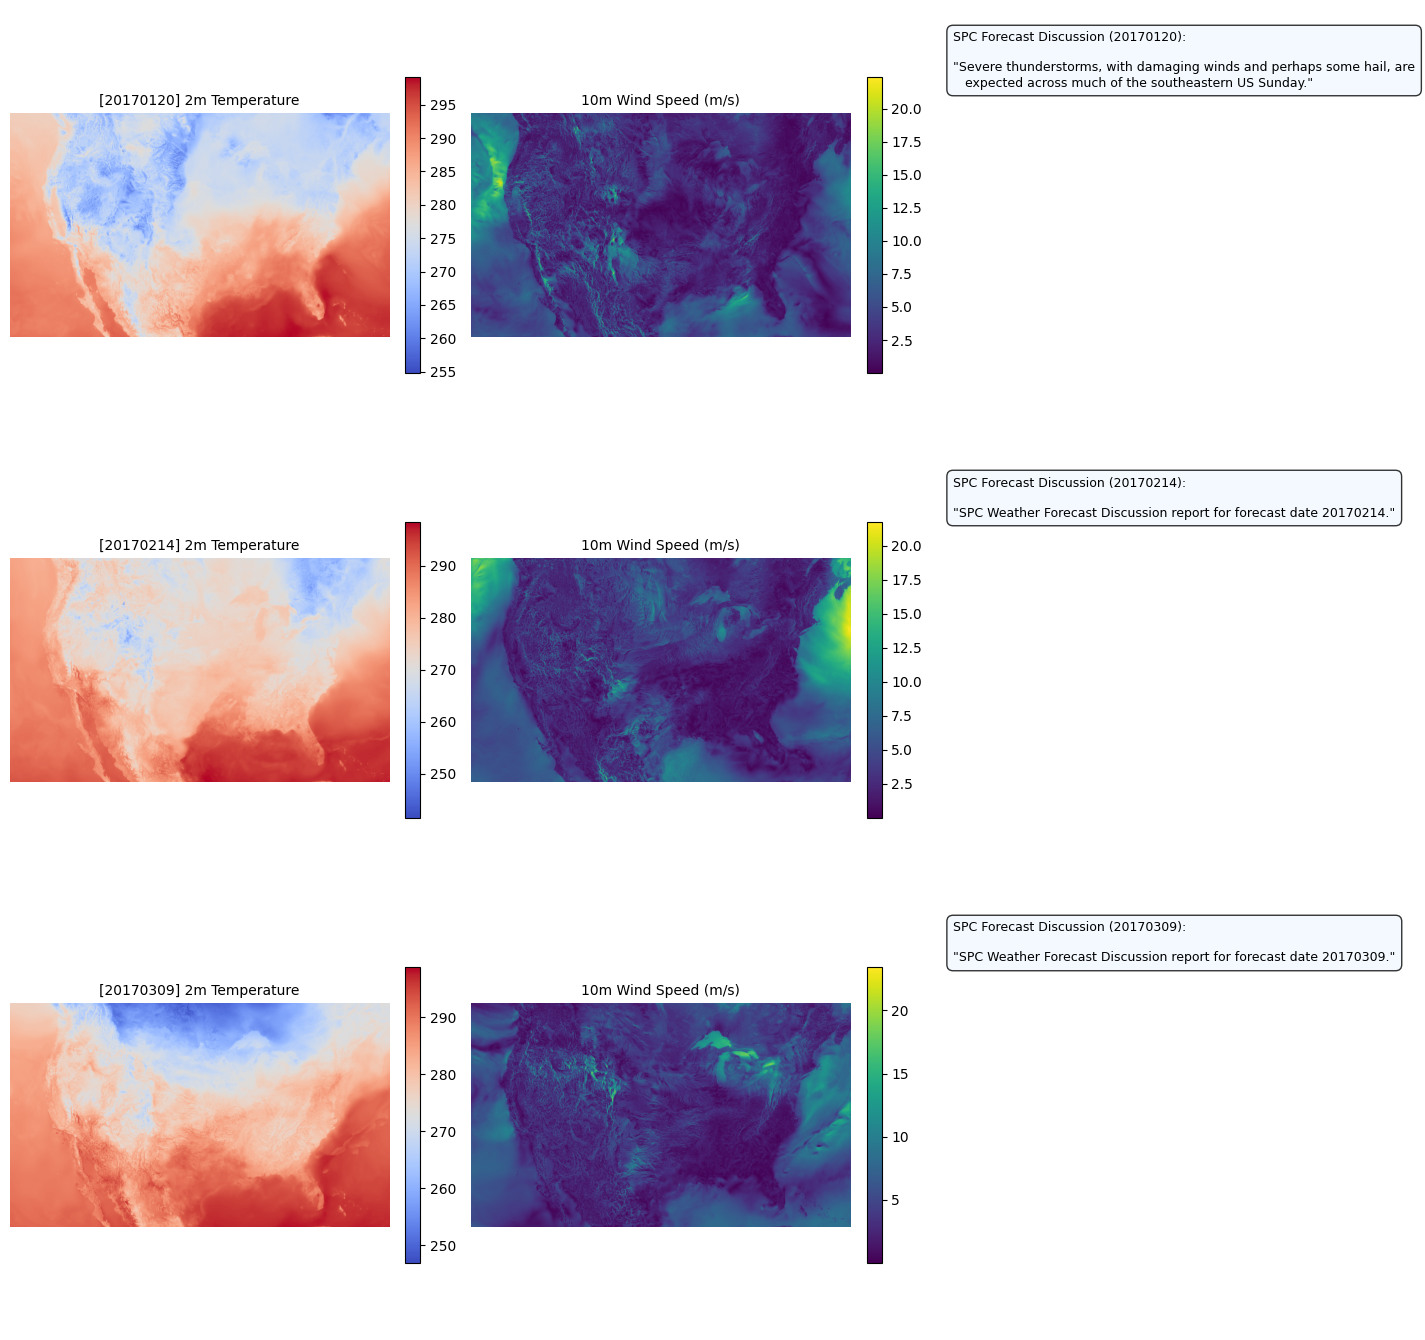

In [11]:
# 9. Visualizing HRRR Weather Fields & Text Discussion
num_records = max(1, len(records_list))
fig, axes = plt.subplots(num_records, 3, figsize=(15, 4.5 * num_records), facecolor="white")
if num_records == 1:
    axes = np.expand_dims(axes, axis=0)

field_names = [
    "2m Temperature (K)",
    "Wind Speed & Vectors",
    "Total Cloud Cover (%)",
]

for idx, batch in enumerate(records_list):
    grid = batch["weather_grid"][0].numpy()  # shape (9, 1059, 1799)
    date_str = batch["date"][0]
    discussion = batch["discussion"][0].strip()
    
    # Field 1: 2m Temperature (index 1) — set origin="lower" for correct CONUS orientation
    temp2m = grid[1]
    im0 = axes[idx, 0].imshow(temp2m, cmap="coolwarm", origin="lower")
    axes[idx, 0].set_title(f"[{date_str}] 2m Temperature", fontsize=10)
    axes[idx, 0].axis("off")
    plt.colorbar(im0, ax=axes[idx, 0], fraction=0.036, pad=0.04)

    # Field 2: Wind Speed from 10m U (index 3) and V (index 4) — set origin="lower"
    u10, v10 = grid[3], grid[4]
    wind_speed = np.sqrt(u10**2 + v10**2)
    im1 = axes[idx, 1].imshow(wind_speed, cmap="viridis", origin="lower")
    axes[idx, 1].set_title("10m Wind Speed (m/s)", fontsize=10)
    axes[idx, 1].axis("off")
    plt.colorbar(im1, ax=axes[idx, 1], fraction=0.036, pad=0.04)

    # Field 3: Text forecast discussion summary box
    axes[idx, 2].axis("off")
    snippet = discussion[:300] + ("..." if len(discussion) > 300 else "")
    axes[idx, 2].text(
        0.05, 0.95,
        f"SPC Forecast Discussion ({date_str}):\n\n\"{snippet}\"",
        transform=axes[idx, 2].transAxes,
        fontsize=9,
        verticalalignment="top",
        wrap=True,
        bbox=dict(boxstyle="round,pad=0.5", facecolor="aliceblue", alpha=0.8),
    )

plt.tight_layout()
plt.show()